In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib
import os

try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    PERSIAN_SUPPORT = True
except ImportError:
    PERSIAN_SUPPORT = False
    print("کتابخانه فارسی نصب نیست")

In [13]:
"""matplotlib ﺗﺒﺪﯾﻞ ﻣﺘﻦ ﻓﺎرﺳﯽ ﺑﺮای ﻧﻤﺎﯾﺶ در"""

def format_persian(text):
    if PERSIAN_SUPPORT:
        return get_display(arabic_reshaper.reshape(text))
    return text
    
"""ﺗﻨﻈﯿﻤﺎت اوﻟﯿﮫ ﺑﺮای ﻧﻤﻮدارھﺎی ﻓﺎرﺳﯽ"""
def setup_persian_plot():
    if PERSIAN_SUPPORT:
        plt.rcParams['font.family'] = 'DejaVu Sans'
    return format_persian

In [22]:
##، در کدی که نوشتید، ویژگی‌ها (X) و هدف (y) 
##را مشخص و مقیاس‌بندی (scale) کرده‌اید.



#فراخوانی تابع برای جداسازی ویژگی‌هاا. 
#(X) و ویژگیها (y) هدف 
#ویژگی‌های مقیاس شده، X
#y = هدف مقیاس شده،
#scaler_X = شیء مقیاس‌کننده ویژگی‌ها (برای بازگردانی بعداً)،
#scaler_y = شیء مقیاس‌کننده هدف."""    
def prepare_features_target(df, target_col, feature_cols=None, scale=True):
    """جداسازی و مقیاس‌بندی ویژگی‌ها و هدف"""
    if feature_cols is None:
        feature_cols = [col for col in df.columns if col != target_col and df[col].dtype in ['float64', 'int64']]
    
    X = df[feature_cols].copy()
    y = df[target_col].copy()
#مقیاس‌بندی آن‌  
    if scale:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()
        return X_scaled, y_scaled, scaler_X, scaler_y
    
    return X.values, y.values, None, None


#فراخوانی
df = pd.read_csv('D:\\paper\\C\\data\\exc\\realityvalues.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# 2. مشخص کردن ستون هدف
target_col = 'En_Requests (MJ)'
# 3. فراخوانی تابع
X_scaled, y_scaled, scaler_X, scaler_y = prepare_features_target(df, target_col, scale=True)
# 4. نمایش خروجی
print("شکل ماتریس ویژگی‌ها:", X_scaled.shape) #شکل ماتریس ویژگی‌ها 
print("پنج مقدار اول ویژگی اول:", X_scaled[:5, 0])  #پنج مقدار اول از ستون اول ویژگی‌ها
print("پنج مقدار اول هدف:", y_scaled[:5])  #پنج مقدار اول از هدف
print("میانگین X_scaled:", X_scaled.mean(axis=0))   #میانگین هر ستون از ویژگی‌های مقیاس‌بندی شده را محاسبه می‌کند. به دلیل خطای محاسباتی اعداد بسیار کوچک خواهید دید که عملاً صفر است
print("انحراف معیار X_scaled:", X_scaled.std(axis=0)) #انحراف معیار هر ستون را نشان می‌دهد- ید دقیقاً ۱ باشد (یا خیلی نزدیک به ۱).
#انحراف معیار هر ستون را نشان می‌دهد. برای StandardScaler باید دقیقاً ۱ باشد (یا خیلی نزدیک به ۱). یعنی هر ویژگی واریانس یک دارد.


شکل ماتریس ویژگی‌ها: (108, 5)
پنج مقدار اول ویژگی اول: [ 1.3547667   0.8178755  -0.0488981  -0.89570532 -1.24647422]
پنج مقدار اول هدف: [ 1.54229604  1.03830786  0.26070074 -0.61751196 -1.03622373]
میانگین X_scaled: [-3.64934420e-16  3.28954970e-17  1.87093139e-16 -6.08566695e-16
  6.37350255e-17]
انحراف معیار X_scaled: [1. 1. 1. 1. 1.]


In [43]:

#def load_and_clean_data(file_path='D:\\paper....csv', index_col='date', handle_outliers=True): تعریف تابع با سه پارامتر ورودی.
#file_path – برای دریافت مسیر فایل داده .
#index_col – برای تعیین ستونی که به عنوان ایندکس دیتافریم استفاده شود.
#handle_outliers – برای فعال/غیرفعال کردن حذف داده‌های پرت (outlier).'''
def load_and_clean_data(file_path= 'D:\\paper\\C\\data\\exc\\realityvalues.csv', index_col='date', handle_outliers=True):
    """
    بارگذاری و پاکسازی داده‌ها با قابلیت حذف outlierها
    """
    df = pd.read_csv(file_path)
    df[index_col] = pd.to_datetime(df[index_col]) #ستون مورد نظر را به نوع تاریخ و زمان تبدیل می‌کند.
    df.set_index(index_col, inplace=True)  #همان ستون را به عنوان ایندکس (برچسب ردیف‌ها) قرار می‌دهد.
    df.sort_index(inplace=True) #ردیف‌ها بر اساس تاریخ صعودی باشند
   

    #  NAN حذف ستون‌های با نال زیاد
    null_pct = df.apply(pd.isnull).sum() / df.shape[0] #تعداد مقادیر نال هر ستون را حساب می‌کند و انهارا به تعداد سطرها تقسیم میکند در نتیجه سبت (درصد) نال بودن هر ستون را به دست می‌آورد
    valid_columns = df.columns[null_pct < 0.05] #قط نام ستون‌هایی را نگه می‌دارد که کمتر از ۵٪ نال دارند
    df = df[valid_columns].copy() #دیتافریم جدیدی فقط از همان ستون‌های معتبر می‌سازد (با کپی کردن)
    
    # تبدیل نام ستون‌ها
    df.columns = df.columns.str.lower()  #همه نام ستون‌های دیتافریم را به حروف کوچک تبدیل می‌کند
     
    
    # پر کردن مقادیر گمشده
    df = df.ffill().bfill()   #دیتافریم با استفاده از مقادیر مجاور (بالا یا پایین) پر می‌شون
    # forward fill با مقدار بالایی خود (قبلی در همان ستون) پر می‌کند
    # backward fill با مقدار پایینی خود (بعدی در همان ستون) پر می‌کند.


    
    # حذف Outlier
    #روش IQR =این روش داده‌های پرت را با استفاده از دامنه بین چارکی حذف می‌کند
    #Q1 = چارک اول (۲۵٪ داده‌ها کمتر از این مقدار)
    #Q3 = چارک سوم (۷۵٪ داده‌ها کمتر از این مقدار)
    #IQR = Q3 – Q1 (محدوده میانی داده‌ها)
    #  Q1 – 3 × IQR  &  Q3 + 3 × IQR
    #هر مقداری که بیرون از این کران‌ها باشد، پرت محسوب شده و حذف می‌گرد
    if handle_outliers:
        for col in df.select_dtypes(include=[np.number]).columns:  #برای هر ستون عددی
            Q1 = df[col].quantile(0.25)  #محاسبه چارک اول (Q1)
            Q3 = df[col].quantile(0.75)  #محاسبه چارک سوم (Q3)
            IQR = Q3 - Q1             #تعیین کران پایین
            lower_bound = Q1 - 3 * IQR
            upper_bound = Q3 + 3 * IQR
            df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]  #حذف ردیف‌هایی که مقدار ستون از این کران‌ها خارج باشد.
    
    return df


# حالا در کد اصلی (بعد از تعریف تابع):
df = load_and_clean_data()

target_col = 'en_requests (mj)'
feature_cols = ['co2_emission (kg)', 'temperature', 'rel_humidity', 'solar_hour', 'wind_speed']


X, y, scaler_X, scaler_y = prepare_features_target(
    df, target_col, feature_cols=feature_cols, scale=True)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(df.head())


            en_requests (mj)  co2_emission (kg)  temperature  rel_humidity  \
date                                                                         
2013-01-01     117956.148100        6706.050347     4.722581     53.850806   
2013-02-01      96721.295220        5529.880088     8.969643     53.705357   
2013-03-01      63957.882600        3631.034783    13.286694     48.274194   
2013-04-01      26955.591150        1775.929938    17.629167     35.912500   
2013-05-01       9313.743056        1007.498740    23.872177     26.903226   

            solar_hour  wind_speed  
date                                
2013-01-01       215.7    2.838710  
2013-02-01       190.8    3.022321  
2013-03-01       210.0    3.451613  
2013-04-01       280.0    4.545833  
2013-05-01       311.4    4.637097  
[[ 1.3547667  -1.46207219  1.18674194 -0.7651592  -1.016049  ]
 [ 0.8178755  -1.01581546  1.17732322 -1.14129779 -0.80795059]
 [-0.0488981  -0.56220475  0.82562241 -0.85126322 -0.32140833]
 [-0.

In [48]:
#ک مدل بسازید و پیش‌بینی بگیرید
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [49]:
## تابع برای ارزیابی کیفیت مدل پیش‌بینی
def evaluate_model(y_true, y_pred, model_name="Model", verbose=True):
    """ارزیابی جامع مدل"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    if verbose:
        print(f"\n{'='*50}")
        print(f"📊 ارزیابی مدل {model_name}")
        print(f"{'='*50}")
        print(f"✅ MAE  : {mae:.4f}")
        print(f"✅ MSE  : {mse:.4f}")
        print(f"✅ RMSE : {rmse:.4f}")
        print(f"✅ R²   : {r2:.4f}")
        print(f"✅ MAPE : {mape:.2f}%")
        print(f"{'='*50}\n")
    
    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2, 'mape': mape}

In [50]:
evaluate_model(y_test, y_pred, model_name="مدل نهایی")


📊 ارزیابی مدل مدل نهایی
✅ MAE  : 0.1416
✅ MSE  : 0.0310
✅ RMSE : 0.1762
✅ R²   : 0.9711
✅ MAPE : 20.73%



{'mae': 0.14156799968958406,
 'mse': 0.031039601378642423,
 'rmse': np.float64(0.1761805930817649),
 'r2': 0.9711301843418835,
 'mape': np.float64(20.729296617464296)}

In [51]:
def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted", save_path=None):
    """نمودار مقایسه با پشتیبانی از فارسی"""
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='w', linewidth=0.5, c='blue')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.xlabel(format_persian("مقادیر واقعی"))
    plt.ylabel(format_persian("مقادیر پیش‌بینی شده"))
    plt.title(format_persian(title))
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


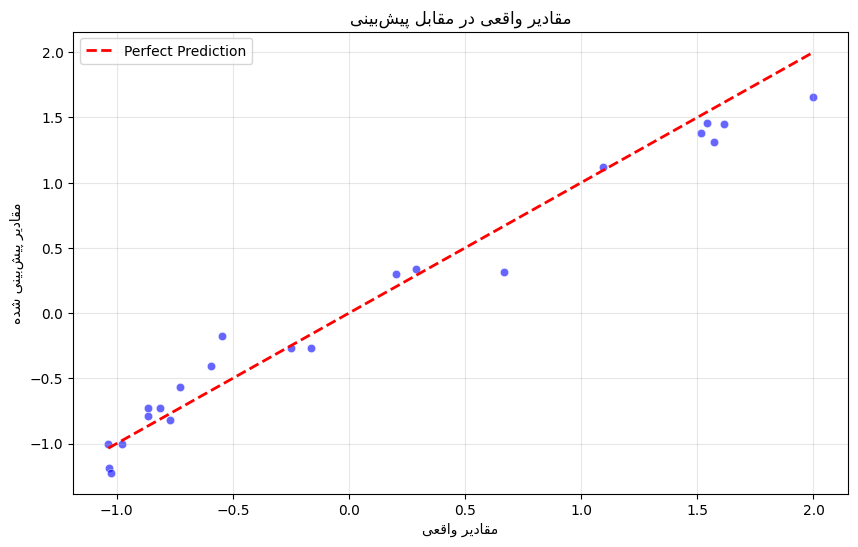

In [52]:
plot_actual_vs_predicted(y_test, y_pred, title="مقادیر واقعی در مقابل پیش‌بینی")

In [53]:

def save_model(model, model_path):
    """ذخیره مدل"""
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    joblib.dump(model, model_path)
    print(f"✅ مدل ذخیره شد: {model_path}")


def load_model(model_path):
    """بارگذاری مدل"""
    return joblib.load(model_path)